<a href="https://colab.research.google.com/github/adithyaashok10/AI-ML-Intership/blob/main/AI_Ml_day_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
path=kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [5]:
import os

file_list=os.listdir(path)
print("Files in the dataset directory:", file_list)

Files in the dataset directory: ['twitter_validation.csv', 'twitter_training.csv']


In [6]:
import pandas as pd
import os

column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

train_df = pd.read_csv(os.path.join(path, 'twitter_training.csv'), header=None, names=column_names)
print('--- Training Data (twitter_training.csv) with fixed headers ---')
display(train_df.head())

--- Training Data (twitter_training.csv) with fixed headers ---


,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [7]:
import pandas as pd
import os

column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']

valid_df = pd.read_csv(os.path.join(path, 'twitter_validation.csv'), header=None, names=column_names)
print('\n--- Validation Data (twitter_validation.csv) with fixed headers ---')
display(valid_df.head())


--- Validation Data (twitter_validation.csv) with fixed headers ---


,Tweet_ID,Entity,Sentiment,Tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [8]:
train_df.to_csv('twitter_training.csv', index=False)
valid_df.to_csv('twitter_validation.csv', index=False)


Generating Sentiment Distribution Chart...


/tmp/ipykernel_469/3767849113.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Number of Tweets')

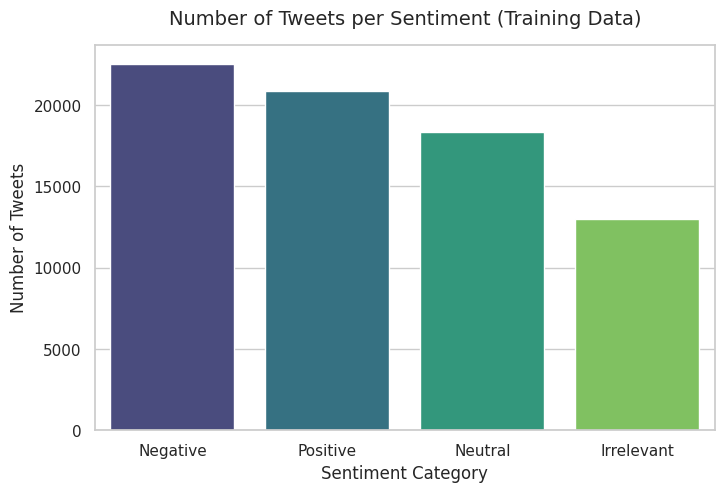

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid")

print("\nGenerating Sentiment Distribution Chart...")

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x='Sentiment',
    order=train_df['Sentiment'].value_counts().index,
    palette='viridis',
    ax=ax
)

ax.set_title('Number of Tweets per Sentiment (Training Data)', fontsize=14, pad=15)
ax.set_xlabel('Sentiment Category', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)


Generating Entity Sentiment Stacked Bar Chart...


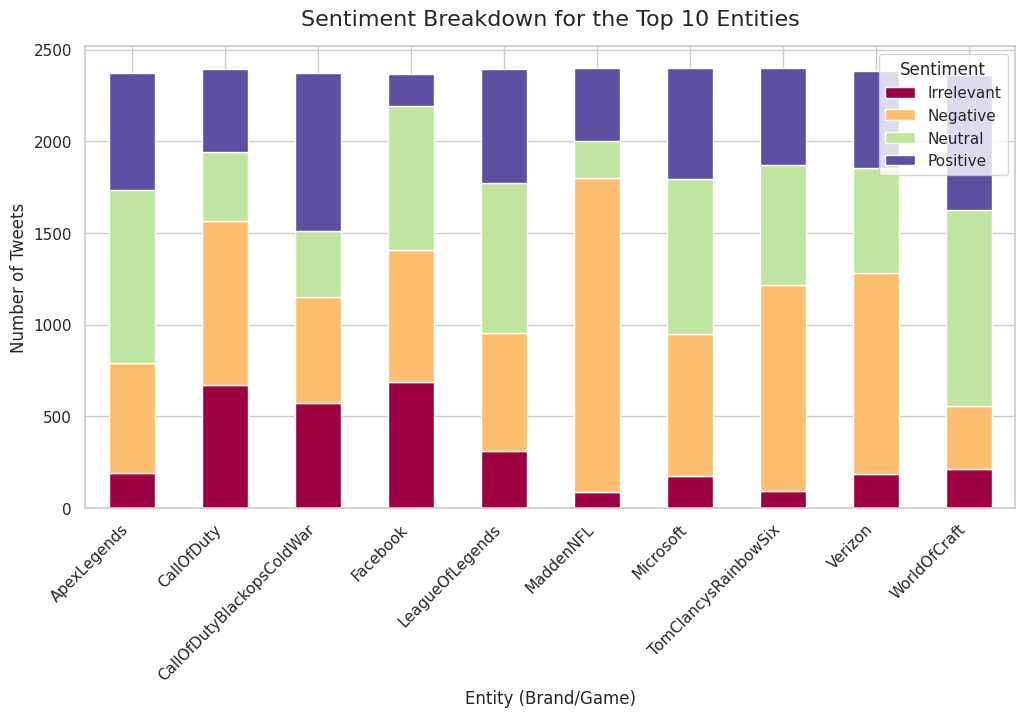

In [10]:
print("\nGenerating Entity Sentiment Stacked Bar Chart...")

top_10_entities = train_df['Entity'].value_counts().nlargest(10).index

top_entities_df = train_df[train_df['Entity'].isin(top_10_entities)]

entity_sentiment_counts = top_entities_df.groupby(['Entity', 'Sentiment']).size().unstack(fill_value=0)

fig3, ax3 = plt.subplots(figsize=(12,6))
entity_sentiment_counts.plot(kind='bar', stacked=True, ax=ax3, colormap='Spectral')

ax3.set_title('Sentiment Breakdown for the Top 10 Entities', fontsize=16, pad=15)
ax3.set_xlabel('Entity (Brand/Game)', fontsize=12)
ax3.set_ylabel('Number of Tweets', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.show()

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet']
train_df.columns = column_names
valid_df.columns = column_names

train_df = train_df.dropna(subset=['Tweet'])
valid_df = valid_df.dropna(subset=['Tweet'])

X_train = train_df['Tweet']
y_train = train_df['Sentiment']

X_valid = valid_df['Tweet']
y_valid = valid_df['Sentiment']

print("Training the classification model... (this takes a few seconds)")

model = make_pipeline(
    TfidfVectorizer(max_features=10000),
    MultinomialNB()
)

model.fit(X_train, y_train)
print("Model training complete!\n")

predictions = model.predict(X_valid)

print("--- Final Evaluation ---")
print(f"Accuracy: {accuracy_score(y_valid, predictions) * 100:.2f}%\n")
print(classification_report(y_valid, predictions))

Training the classification model... (this takes a few seconds)
Model training complete!

--- Final Evaluation ---
Accuracy: 73.80%

              precision    recall  f1-score   support

  Irrelevant       0.89      0.55      0.68       172
    Negative       0.66      0.86      0.75       266
     Neutral       0.83      0.61      0.71       285
    Positive       0.71      0.86      0.78       277

    accuracy                           0.74      1000
   macro avg       0.77      0.72      0.73      1000
weighted avg       0.76      0.74      0.73      1000



Generating Confusion Matrix Heatmap...


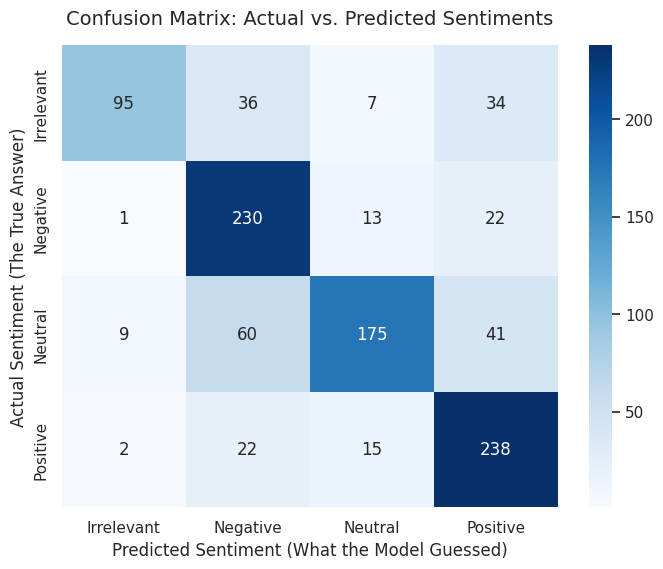

In [12]:
print("Generating Confusion Matrix Heatmap...")

cm = confusion_matrix(y_valid, predictions, labels=model.classes_)

fig2, ax2 = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    ax=ax2
)

ax2.set_title('Confusion Matrix: Actual vs. Predicted Sentiments', fontsize=14, pad=15)
ax2.set_xlabel('Predicted Sentiment (What the Model Guessed)', fontsize=12)
ax2.set_ylabel('Actual Sentiment (The True Answer)', fontsize=12)

plt.show()

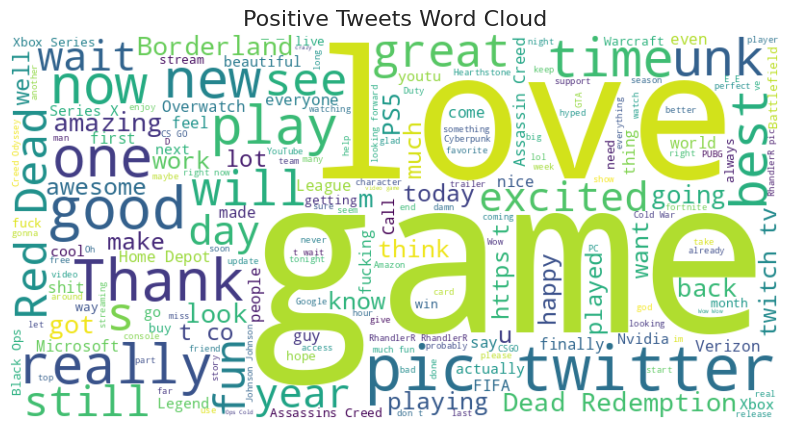

In [13]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

positive_text = " ".join(train_df[train_df['Sentiment'] == 'Positive']['Tweet'].astype(str))

simple_cloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

plt.figure(figsize=(10, 5))
plt.imshow(simple_cloud, interpolation='bilinear')
plt.axis("off")
plt.title("Positive Tweets Word Cloud", fontsize=16)
plt.show()